# Energy Consumption Forecasting — Data Cleaning & Feature Engineering

This notebook prepares the raw PJM hourly time series for modelling.  We parse and
sort timestamps, remove duplicates, and engineer the calendar, lag, and rolling-mean
features that will serve as predictors in notebook 03.

## 1. Imports & Load Data

We import our project utilities (which house the `create_features` function) and
load the raw dataset with the `Datetime` column parsed to a native datetime type.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '.')
from utils import load_data, create_features

sns.set_style('whitegrid')
%matplotlib inline

df = load_data('data/PJME_hourly.csv')
print('Raw shape:', df.shape)
print(df.dtypes)
df.head()

Raw shape: (145366, 2)
Datetime    datetime64[ns]
PJME_MW            float64
dtype: object


,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


## 2. Parse, Sort, and Deduplicate Timestamps

The raw file may have duplicate or out-of-order rows.  We sort ascending by
`Datetime`, drop exact duplicate timestamps, and verify a clean monotonic index
before engineering any features.

In [2]:
# Sort ascending
df = df.sort_values('Datetime').reset_index(drop=True)

# Check for duplicate timestamps
n_dupes = df.duplicated(subset=['Datetime']).sum()
print(f'Duplicate Datetime rows: {n_dupes}')
df = df.drop_duplicates(subset=['Datetime']).reset_index(drop=True)

# Verify date range and monotonicity
print(f'Date range: {df["Datetime"].min()}  →  {df["Datetime"].max()}')
print(f'Monotonic ascending: {df["Datetime"].is_monotonic_increasing}')
print(f'Shape after dedup: {df.shape}')
df.head()

Duplicate Datetime rows: 4
Date range: 2002-01-01 01:00:00  →  2018-08-03 00:00:00
Monotonic ascending: True
Shape after dedup: (145362, 2)


,Datetime,PJME_MW
0,2002-01-01 01:00:00,30393.0
1,2002-01-01 02:00:00,29265.0
2,2002-01-01 03:00:00,28357.0
3,2002-01-01 04:00:00,27899.0
4,2002-01-01 05:00:00,28057.0


## 3. Calendar Feature Engineering

Calendar features capture the deterministic, repeating seasonality in energy demand.
Hour-of-day drives the daily load curve; day-of-week separates weekdays from weekends;
month and quarter capture annual heating/cooling cycles; `is_weekend` is a simple
binary signal for the weekday/weekend demand gap.

In [3]:
df['hour']       = df['Datetime'].dt.hour
df['dayofweek']  = df['Datetime'].dt.dayofweek   # 0=Mon, 6=Sun
df['month']      = df['Datetime'].dt.month
df['quarter']    = df['Datetime'].dt.quarter
df['year']       = df['Datetime'].dt.year
df['dayofyear']  = df['Datetime'].dt.dayofyear
df['weekofyear'] = df['Datetime'].dt.isocalendar().week.astype(int)
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

print('Calendar features added. Shape:', df.shape)
df[['Datetime','PJME_MW','hour','dayofweek','month','quarter',
    'year','dayofyear','weekofyear','is_weekend']].head(8)

Calendar features added. Shape: (145362, 10)


,Datetime,PJME_MW,hour,dayofweek,month,quarter,year,dayofyear,weekofyear,is_weekend
0,2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1,1,0
1,2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1,1,0
2,2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1,1,0
3,2002-01-01 04:00:00,27899.0,4,1,1,1,2002,1,1,0
4,2002-01-01 05:00:00,28057.0,5,1,1,1,2002,1,1,0
5,2002-01-01 06:00:00,28654.0,6,1,1,1,2002,1,1,0
6,2002-01-01 07:00:00,29308.0,7,1,1,1,2002,1,1,0
7,2002-01-01 08:00:00,29595.0,8,1,1,1,2002,1,1,0


## 4. Lag & Rolling-Mean Feature Engineering

Lag features capture autocorrelation: `lag_24` is the consumption at exactly the
same hour yesterday; `lag_168` is the same hour one week ago.  Rolling means
(`roll_24`, `roll_168`) smooth short-term noise while still providing recent context.

**No data leakage**: every lag is shifted *forward* by its window length so that
each row only depends on strictly past observations.  The rolling windows are
computed on the already-shifted series (`shift(1)`) for the same reason — the
current hour's own value is never included in its own window.

In [4]:
df['lag_24']  = df['PJME_MW'].shift(24)
df['lag_168'] = df['PJME_MW'].shift(168)
df['roll_24']  = df['PJME_MW'].shift(1).rolling(window=24).mean()
df['roll_168'] = df['PJME_MW'].shift(1).rolling(window=168).mean()

print('Lag / rolling features added.')
print(f'NaN rows introduced: {df.isnull().any(axis=1).sum()}')
df[['Datetime','PJME_MW','lag_24','lag_168','roll_24','roll_168']].tail(5)

Lag / rolling features added.
NaN rows introduced: 168


,Datetime,PJME_MW,lag_24,lag_168,roll_24,roll_168
145357,2018-08-02 20:00:00,44057.0,46912.0,46337.0,40021.875000,35913.809524
145358,2018-08-02 21:00:00,43256.0,45985.0,44542.0,39902.916667,35900.238095
145359,2018-08-02 22:00:00,41552.0,44094.0,42638.0,39789.208333,35892.583333
145360,2018-08-02 23:00:00,38500.0,40666.0,39276.0,39683.291667,35886.119048
145361,2018-08-03 00:00:00,35486.0,37158.0,35742.0,39593.041667,35881.500000


## 5. Drop NaN Rows — Final Shape

The first 168 rows will have NaN in `lag_168` (and the rolling windows similarly).
We drop them entirely rather than impute, since for a time-series model substituting
historical averages into the warmup period would introduce artificial data.

In [5]:
before = len(df)
df = df.dropna().reset_index(drop=True)
after = len(df)
print(f'Dropped {before - after} NaN rows ({(before-after)/before*100:.1f}%)')
print(f'Final shape: {df.shape}')
print('\nMissing values after drop:')
print(df.isnull().sum())
df.head(3)

Dropped 168 NaN rows (0.1%)
Final shape: (145194, 14)

Missing values after drop:
Datetime      0
PJME_MW       0
hour          0
dayofweek     0
month         0
quarter       0
year          0
dayofyear     0
weekofyear    0
is_weekend    0
lag_24        0
lag_168       0
roll_24       0
roll_168      0
dtype: int64


,Datetime,PJME_MW,hour,dayofweek,month,quarter,year,dayofyear,weekofyear,is_weekend,lag_24,lag_168,roll_24,roll_168
0,2002-01-08 01:00:00,29445.0,1,1,1,1,2002,8,2,0,26862.0,30393.0,33452.583333,32519.511905
1,2002-01-08 02:00:00,28670.0,2,1,1,1,2002,8,2,0,25976.0,29265.0,33560.208333,32513.869048
2,2002-01-08 03:00:00,28375.0,3,1,1,1,2002,8,2,0,25641.0,28357.0,33672.458333,32510.327381


## 6. Lag Feature Correlation with Target

A scatter plot of `lag_24` vs `PJME_MW` (sampled for speed) confirms that the same
hour yesterday is a powerful predictor of today's demand.  We also compute the
Pearson correlation of all engineered features with the target.

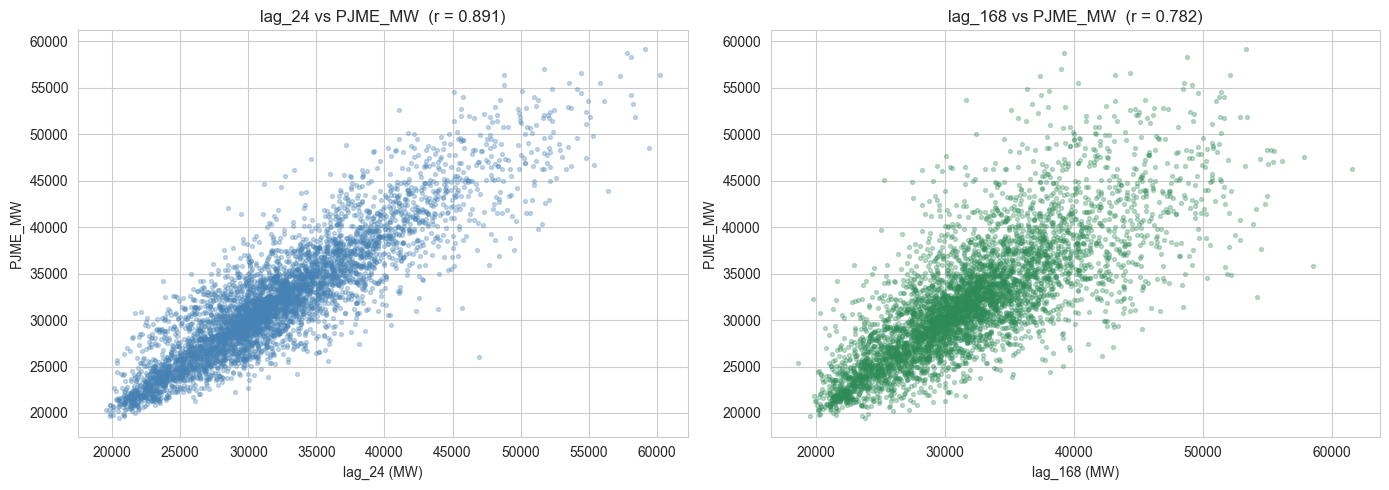

In [6]:
sample = df.sample(5000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(sample['lag_24'], sample['PJME_MW'],
                alpha=0.3, s=8, color='steelblue')
axes[0].set_xlabel('lag_24 (MW)')
axes[0].set_ylabel('PJME_MW')
axes[0].set_title(f'lag_24 vs PJME_MW  (r = {df["lag_24"].corr(df["PJME_MW"]):.3f})')

axes[1].scatter(sample['lag_168'], sample['PJME_MW'],
                alpha=0.3, s=8, color='seagreen')
axes[1].set_xlabel('lag_168 (MW)')
axes[1].set_ylabel('PJME_MW')
axes[1].set_title(f'lag_168 vs PJME_MW  (r = {df["lag_168"].corr(df["PJME_MW"]):.3f})')

plt.tight_layout()
plt.show()

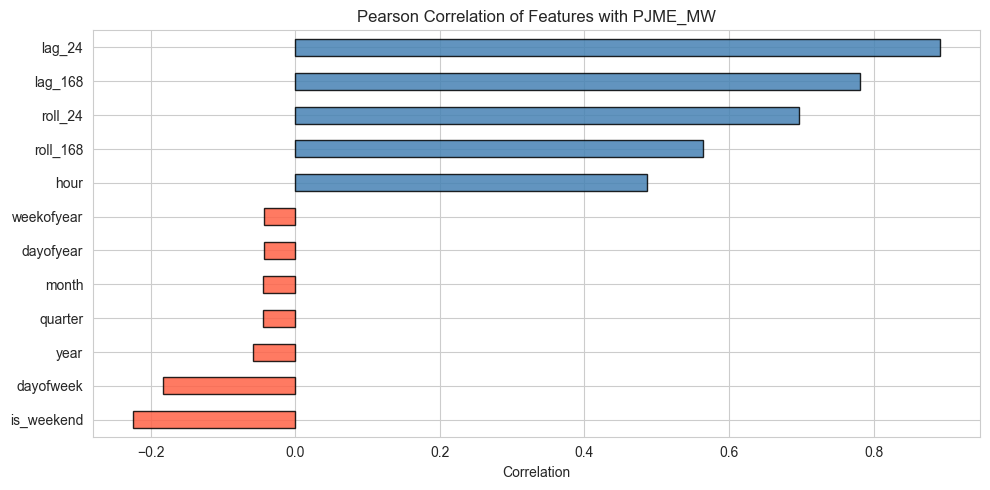

is_weekend   -0.224
dayofweek    -0.183
year         -0.058
quarter      -0.045
month        -0.044
dayofyear    -0.044
weekofyear   -0.044
hour          0.486
roll_168      0.564
roll_24       0.696
lag_168       0.782
lag_24        0.891
Name: PJME_MW, dtype: float64


In [7]:
feature_cols = ['hour','dayofweek','month','quarter','year','dayofyear',
                'weekofyear','is_weekend','lag_24','lag_168','roll_24','roll_168']
corr = df[feature_cols + ['PJME_MW']].corr()['PJME_MW'].drop('PJME_MW').sort_values()

plt.figure(figsize=(10, 5))
corr.plot(kind='barh', color=['tomato' if v < 0 else 'steelblue' for v in corr.values],
          edgecolor='black', alpha=0.85)
plt.title('Pearson Correlation of Features with PJME_MW')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()
print(corr.round(3))

## 7. Save Cleaned Feature CSV

We save the fully engineered DataFrame to `data/energy_features.csv`.
Notebook 03 will load this file directly for model training.

In [8]:
out_path = 'data/energy_features.csv'
df.to_csv(out_path, index=False)
print(f'Saved {len(df):,} rows to {out_path}')
print('Columns:', list(df.columns))

Saved 145,194 rows to data/energy_features.csv
Columns: ['Datetime', 'PJME_MW', 'hour', 'dayofweek', 'month', 'quarter', 'year', 'dayofyear', 'weekofyear', 'is_weekend', 'lag_24', 'lag_168', 'roll_24', 'roll_168']
